# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement the search algorithm BFS for planning paths through mazes.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [50]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "large_maze.txt", "open_maze.txt", "empty_maze.txt"]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [51]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [52]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

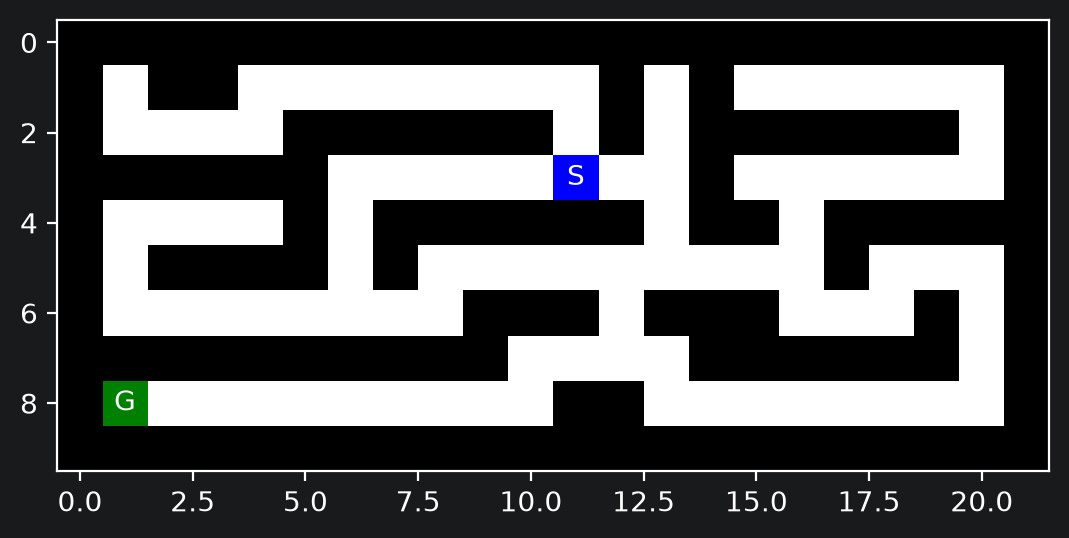

In [53]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [54]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [55]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

        Para

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [56]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [57]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['W', 'S', 'S', 'N', 'W', 'E', 'W', 'S', 'E', 'W']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [58]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: S
Following plan... step 1: N
Following plan... step 2: E
Following plan... step 3: N
Following plan... step 4: W
Following plan... step 5: N
Following plan... step 6: S
Following plan... step 7: W
Following plan... step 8: W
Following plan... step 9: N
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [59]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithm for solving different mazes:
    - Breadth-first search (BFS)

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt), and
    - [empty maze](empty_maze.txt).

3. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [2 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

`<Your answer goes here>`

Give some estimates for the problem size:

* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

`<Your answer goes here>`

## Task 2: Breadth-First Search [5 Points]

Implement this simple search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important note** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.


Maze                Path length    Nodes expanded 
--------------------------------------------------
small_maze.txt      19             90             
large_maze.txt      210            617            
open_maze.txt       54             679            
empty_maze.txt      14             92             
=== small_maze.txt ===


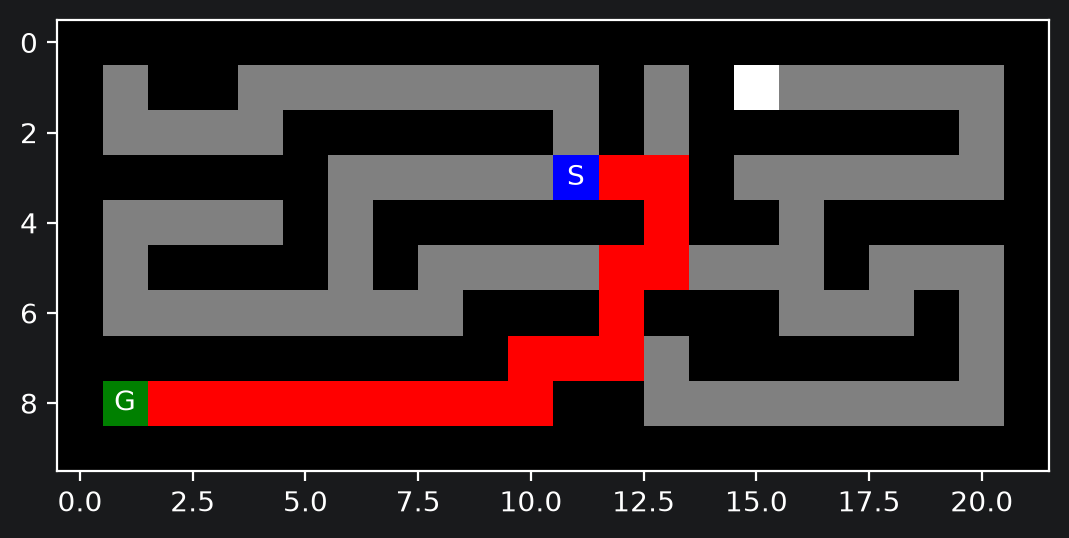

=== large_maze.txt ===


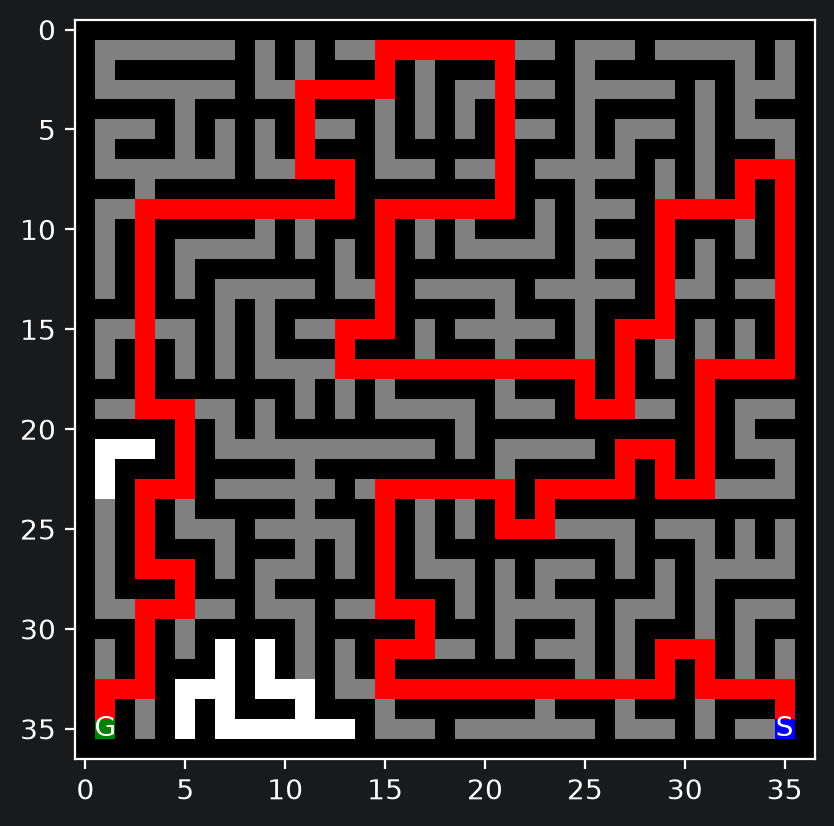

=== open_maze.txt ===


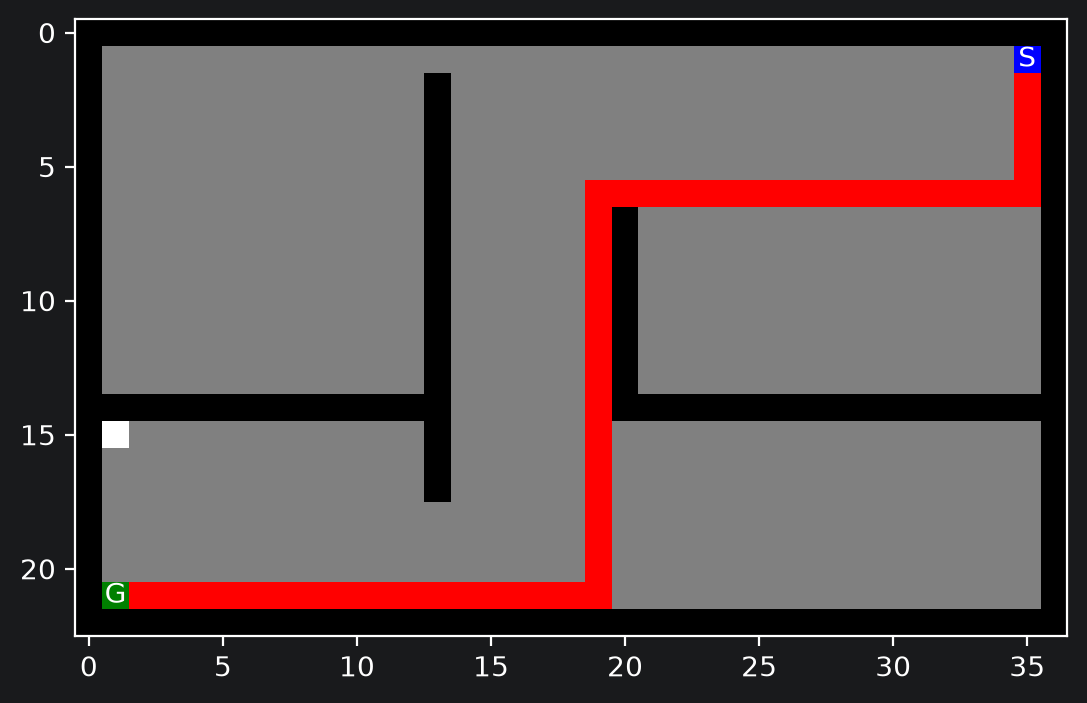

=== empty_maze.txt ===


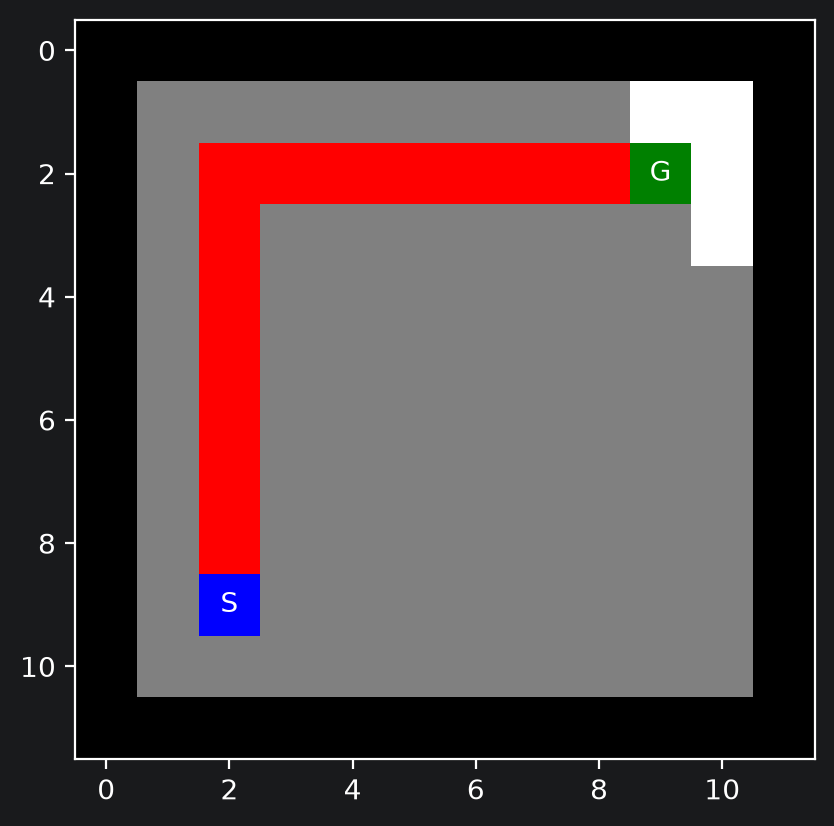

In [60]:
from collections import deque
import maze_helper as mh

# ============================================================
# 1) HÀM BỔ TRỢ CHO BÀI TOÁN TÌM KIẾM MÊ CUNG
# ============================================================
MOVES = {
    "N": (-1,  0),   # lên  = giảm row
    "S": ( 1,  0),   # xuống = tăng row
    "E": ( 0,  1),   # phải  = tăng col
    "W": ( 0, -1),   # trái  = giảm col
}

def valid_actions(maze, pos):
    """Trả về các hành động hợp lệ từ pos (không đâm vào tường 'X' và không ra biên)."""
    r, c = pos
    result = []
    for a, (dr, dc) in MOVES.items():
        nr, nc = r + dr, c + dc
        if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1] and maze[nr, nc] != 'X':
            result.append(a)
    return result

def result_state(pos, action):
    """Transition model: trạng thái mới khi áp dụng action tại pos."""
    dr, dc = MOVES[action]
    return (pos[0] + dr, pos[1] + dc)


# ============================================================
# 2) BFS – Breadth-First Search (pseudocode Figure 3.9 - AIMA)
# ============================================================
def plan_bfs(maze, start, goal):
    """
    Tìm đường đi ngắn nhất từ start đến goal bằng BFS.
    KHÔNG lưu thông tin vào maze – chỉ dùng cây tìm kiếm, frontier, reached.
    Trả về: (actions, path_positions, reached, nodes_expanded)
    """
    start, goal = tuple(start), tuple(goal)
    root = Node(pos=start, parent=None, action=None, cost=0)

    if start == goal:
        return [], [start], {start}, 0

    frontier = deque([root])   # FIFO queue
    reached  = {start}         # state đã sinh
    nodes_expanded = 0

    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1

        for a in valid_actions(maze, node.pos):
            child_pos = result_state(node.pos, a)
            if child_pos not in reached:
                child = Node(pos=child_pos, parent=node, action=a, cost=node.cost + 1)

                # Goal test NGAY khi sinh node con (đúng pseudocode)
                if child_pos == goal:
                    path_nodes = child.get_path_from_root()
                    path_pos  = [n.pos for n in path_nodes]
                    path_act  = [n.action for n in path_nodes[1:]]
                    return path_act, path_pos, reached, nodes_expanded

                reached.add(child_pos)
                frontier.append(child)

    return None, None, reached, nodes_expanded   # thất bại


# ============================================================
# 3) CHẠY BFS TRÊN 4 MÊ CUNG VÀ IN BẢNG KẾT QUẢ
# ============================================================
maze_files = ["small_maze.txt", "large_maze.txt", "open_maze.txt", "empty_maze.txt"]

maze_dict = {}
for fname in maze_files:
    with open(fname, "r") as f:
        maze_dict[fname] = mh.parse_maze(f.read())

bfs_results = {}
for fname, m in maze_dict.items():
    s = mh.find_pos(m, what="S")
    g = mh.find_pos(m, what="G")
    actions, path, reached, expanded = plan_bfs(m, s, g)
    bfs_results[fname] = dict(actions=actions, path=path,
                              reached=reached, expanded=expanded)

print(f"{'Maze':<20}{'Path length':<15}{'Nodes expanded':<15}")
print("-" * 50)
for fname, res in bfs_results.items():
    print(f"{fname:<20}{len(res['actions']):<15}{res['expanded']:<15}")


# ============================================================
# 4) TRỰC QUAN HÓA LỜI GIẢI (. = đã thăm, P = đường đi)
# ============================================================
def visualize_solution(maze, path, reached, title=""):
    viz = maze.copy()
    for (r, c) in reached:
        if viz[r, c] == ' ':
            viz[r, c] = '.'
    for (r, c) in path:
        if viz[r, c] not in ('S', 'G'):
            viz[r, c] = 'P'
    print(f"=== {title} ===")
    mh.show_maze(viz)

for fname, res in bfs_results.items():
    visualize_solution(maze_dict[fname], res["path"], res["reached"], title=fname)

The result of the planning function is a sequence of actions. Fill out the following table:


| maze | path length | # of nodes expanded |
|-----------|-----------|------------------|
| small     |           |                  |
| large     |           |                  |
| open      |           |                  |
| empty     |           |                  |

Visualize the found path for each maze. You can look at the `show_maze()` function in [maze_helper.py](maze_helper.py) to see how you can visualize the path.

In [61]:
import pandas as pd

# Tạo DataFrame từ kết quả BFS
df = pd.DataFrame([
    {
        "maze": fname.replace("_maze.txt", ""),
        "path length": len(res["actions"]),
        "# of nodes expanded": res["expanded"],
    }
    for fname, res in bfs_results.items()
])

df

,maze,path length,# of nodes expanded
0,small,19,90
1,large,210,617
2,open,54,679
3,empty,14,92


# Task 3: Discussion [3 Points] 

Is your implementation complete and optimal? Explain why. What is the time and space complexity of each of **your** implementation?

`<Discussion goes here>`

How would the planning improve if you use informed search with A* search and the Euclidean distance to the goal as the heuristic? What would the algorithm do differently?

`<Discussion goes here>`

Your BFS implementation works fine to solve small mazes. Why would it not work for larger problems with millions of states and 100s of actions? What algorithm could be used then?

`<Discussion goes here>`